In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/PBC_DATA"

TRAIN_CSV = f"{DATA_ROOT}/pbc_attr_v1_train.csv"
VAL_CSV   = f"{DATA_ROOT}/pbc_attr_v1_val.csv"

IMAGE_ROOT = f"{DATA_ROOT}/data"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, random, json
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets.folder import default_loader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

def make_deterministic(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [ ]:
att_names = [
    "cell_size", "cell_shape", "nucleus_shape",
    "nuclear_cytoplasmic_ratio", "chromatin_density",
    "cytoplasm_vacuole", "cytoplasm_texture",
    "cytoplasm_colour", "granule_type",
    "granule_colour", "granularity"
]


In [ ]:
class AttDataset(Dataset):
    def __init__(self, csv_file, attribute_columns, image_dir,
                 transform=None, attribute_encoders=None, cell_encoder=None):

        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        self.attribute_columns = attribute_columns

        # Attribute encoders
        if attribute_encoders is None:
            self.attribute_encoders = {
                col: {v: i for i, v in enumerate(sorted(self.df[col].unique()))}
                for col in attribute_columns
            }
        else:
            self.attribute_encoders = attribute_encoders

        # 🔹 CELL TYPE encoder (from "label" column)
        if cell_encoder is None:
            self.cell_encoder = {
                v: i for i, v in enumerate(sorted(self.df["label"].unique()))
            }
        else:
            self.cell_encoder = cell_encoder

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.df.loc[idx, "path"])
        image = default_loader(img_path)

        attr_labels = [
            self.attribute_encoders[col][self.df.loc[idx, col]]
            for col in self.attribute_columns
        ]

        cell_label = self.cell_encoder[self.df.loc[idx, "label"]]

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "attributes": torch.tensor(attr_labels, dtype=torch.long),
            "cell_type": torch.tensor(cell_label, dtype=torch.long),
            "img_path": img_path
        }


In [ ]:
def get_transforms(train=True):
    if train:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
        ])


In [ ]:
import torchvision
import torch.nn as nn

def get_image_encoder(backbone="resnet50", pretrained=True):
    weights = "DEFAULT" if pretrained else None

    if backbone == "vgg16":
        model = torchvision.models.vgg16(weights=weights)
        model.classifier[6] = nn.Identity()
        feat_dim = 4096

    elif backbone == "resnet50":
        model = torchvision.models.resnet50(weights=weights)
        feat_dim = model.fc.in_features
        model.fc = nn.Identity()

    elif backbone == "convnext_tiny":
        model = torchvision.models.convnext_tiny(weights=weights)
        feat_dim = model.classifier[-1].in_features
        model.classifier[-1] = nn.Identity()

    elif backbone == "vit_b_16":
        model = torchvision.models.vit_b_16(weights=weights)
        feat_dim = model.heads.head.in_features
        model.heads = nn.Identity()

    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    return model, feat_dim


In [ ]:
class AttributePredictor(nn.Module):
    def __init__(self, image_encoder, feature_dim, attribute_sizes, num_cell_types):
        super().__init__()
        self.encoder = image_encoder

        # 🔹 Cell-type head
        self.cell_head = nn.Linear(feature_dim, num_cell_types)

        # 🔹 Attribute heads
        self.attr_heads = nn.ModuleList([
            nn.Linear(feature_dim, size) for size in attribute_sizes
        ])

    def forward(self, x):
        features = self.encoder(x)

        cell_logits = self.cell_head(features)
        attr_outputs = [head(features) for head in self.attr_heads]

        return cell_logits, attr_outputs


In [ ]:
def calculate_metrics(y_true, y_prob):
    y_pred = np.argmax(y_prob, axis=1)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "precision": precision_score(y_true, y_pred, average="macro"),
        "recall": recall_score(y_true, y_pred, average="macro")
    }


In [ ]:
SAVE_DIR = "/content/drive/MyDrive/vgg16_saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)


vgg16

In [ ]:
make_deterministic(1)

train_ds = AttDataset(
    TRAIN_CSV,
    att_names,
    IMAGE_ROOT,
    get_transforms(True)
)

val_ds = AttDataset(
    VAL_CSV,
    att_names,
    IMAGE_ROOT,
    get_transforms(False),
    attribute_encoders=train_ds.attribute_encoders,
    cell_encoder=train_ds.cell_encoder
)

num_cell_types = len(train_ds.cell_encoder)


train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)

encoder, feat_dim = get_image_encoder("vgg16")

attr_sizes = [len(train_ds.attribute_encoders[a]) for a in att_names]

model = AttributePredictor(
    encoder,
    feat_dim,
    attr_sizes,
    num_cell_types
).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 20
save_every = 5

best_val_acc = 0.0
best_epoch = -1
best_model_path = None

val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        imgs = batch["image"].to(device)
        attr_targets = batch["attributes"].to(device)
        cell_targets = batch["cell_type"].to(device)

        optimizer.zero_grad()

        cell_logits, attr_outputs = model(imgs)

        loss_cell = criterion(cell_logits, cell_targets)

        loss_attr = sum(
            criterion(o, attr_targets[:, i])
            for i, o in enumerate(attr_outputs)
        ) / len(attr_outputs)

        loss = loss_cell + loss_attr
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # -------- VALIDATION (CELL TYPE ACCURACY) --------
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch in val_loader:
            imgs = batch["image"].to(device)
            targets = batch["cell_type"].to(device)

            logits, _ = model(imgs)
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    val_acc = accuracy_score(all_targets, all_preds)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Cell Accuracy: {val_acc:.4f}"
    )

    # -------- SAVE MODEL EVERY 5 EPOCHS --------
    if (epoch + 1) % save_every == 0:
        save_path = f"{SAVE_DIR}/vgg_16_epoch_{epoch+1}.pth"
        torch.save({
            "epoch": epoch + 1,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_accuracy": val_acc
        }, save_path)
        print(f"✔ Saved model at epoch {epoch+1}")

    # -------- TRACK BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        best_model_path = f"{SAVE_DIR}/best_model.pth"

        torch.save({
            "epoch": best_epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_accuracy": best_val_acc
        }, best_model_path)



Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 96.6MB/s]


Epoch 1/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.6300 | Val Cell Accuracy: 0.9913


Epoch 2/20:   0%|          | 0/193 [00:00<?, ?it/s]

...

Epoch 18 | Train Loss: 0.1634 | Val Cell Accuracy: 0.9951


Epoch 19/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 19 | Train Loss: 0.1591 | Val Cell Accuracy: 0.9932


Epoch 20/20:   0%|          | 0/193 [00:00<?, ?it/s]

Epoch 20 | Train Loss: 0.1450 | Val Cell Accuracy: 0.9961
✔ Saved model at epoch 20


MODEL EVALUATION (CELL TYPE)

In [ ]:
print("\n==============================")
print(f" BEST MODEL FOUND AT EPOCH: {best_epoch}")
print(f" BEST VALIDATION ACCURACY: {best_val_acc:.4f}")
print(f" MODEL PATH: {best_model_path}")
print("==============================\n")




 BEST MODEL FOUND AT EPOCH: 20
 BEST VALIDATION ACCURACY: 0.9961
 MODEL PATH: /content/drive/MyDrive/vgg16_saved_models/best_model.pth



In [ ]:
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state"])
model.to(device)
model.eval()

AttributePredictor(
  (encoder): VGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_targets = []

with torch.no_grad():
    for batch in val_loader:
        imgs = batch["image"].to(device)
        cell_targets = batch["cell_type"].to(device)

        cell_logits, _ = model(imgs)

        preds = torch.argmax(cell_logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(cell_targets.cpu().numpy())

y_pred = np.array(all_preds)
y_test = np.array(all_targets)


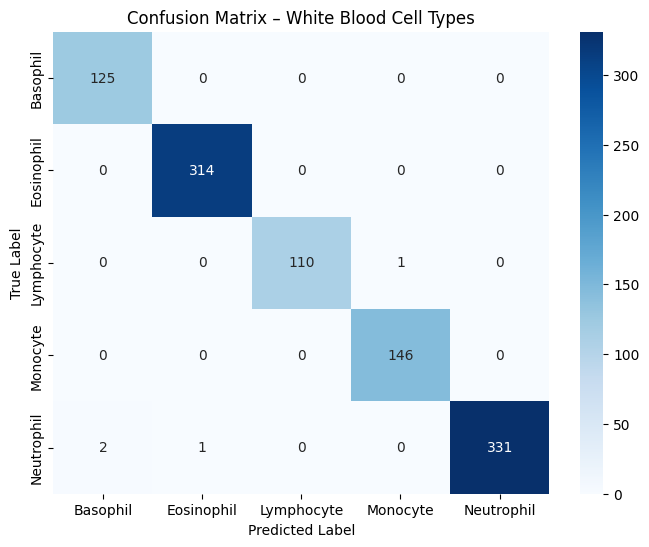

In [ ]:
# Decode class names
inv_cell_encoder = {v: k for k, v in train_ds.cell_encoder.items()}
class_names = [inv_cell_encoder[i] for i in range(len(inv_cell_encoder))]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – White Blood Cell Types")
plt.show()


In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Keep only useful columns
report_df = report_df[["precision", "recall", "f1-score", "support"]]

report_df


,precision,recall,f1-score,support
Basophil,0.984252,1.000000,0.992063,125.000000
Eosinophil,0.996825,1.000000,0.998410,314.000000
Lymphocyte,1.000000,0.990991,0.995475,111.000000
Monocyte,0.993197,1.000000,0.996587,146.000000
Neutrophil,1.000000,0.991018,0.995489,334.000000
accuracy,0.996117,0.996117,0.996117,0.996117
macro avg,0.994855,0.996402,0.995605,1030.000000
weighted avg,0.996157,0.996117,0.996118,1030.000000


In [ ]:
accuracy = (y_test == y_pred).mean()
print(f"Overall Cell-Type Accuracy: {accuracy:.4f}")


Overall Cell-Type Accuracy: 0.9961


Attribute Type evaluation

In [ ]:
def evaluate(model, loader, att_names, device):
    model.eval()
    num_attr = len(att_names)

    probs = [[] for _ in range(num_attr)]
    labels = [[] for _ in range(num_attr)]

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            targets = batch["attributes"].to(device)

            # 🔹 UNPACK OUTPUTS
            cell_logits, attr_outputs = model(imgs)

            for i, out in enumerate(attr_outputs):
                p = torch.softmax(out, dim=1).cpu().numpy()
                probs[i].extend(p)
                labels[i].extend(targets[:, i].cpu().numpy())

    metrics_list = []
    for i, name in enumerate(att_names):
        preds = np.argmax(probs[i], axis=1)

        acc = accuracy_score(labels[i], preds)
        f1 = f1_score(labels[i], preds, average="weighted")
        prec = precision_score(labels[i], preds, average="weighted")

        metrics_list.append([name, acc, f1, prec])

        # Confusion matrix
        cm = confusion_matrix(labels[i], preds)
        plt.figure(figsize=(4,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Confusion Matrix: {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    metrics_df = pd.DataFrame(
        metrics_list,
        columns=["Attribute", "Accuracy", "F1-Score", "Precision"]
    )

    print("\n=== Attribute-wise Metrics ===")
    print(metrics_df)

    return metrics_df


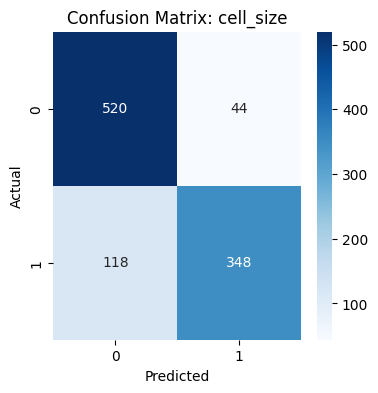

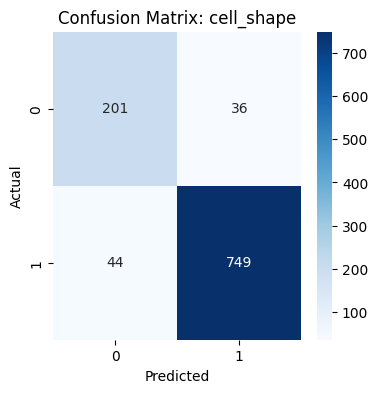

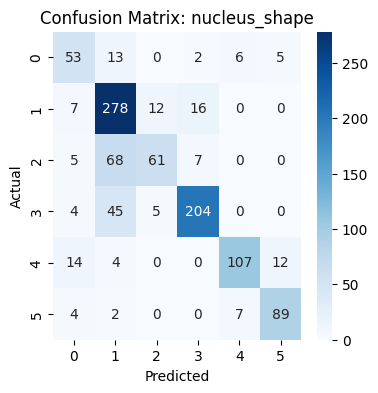

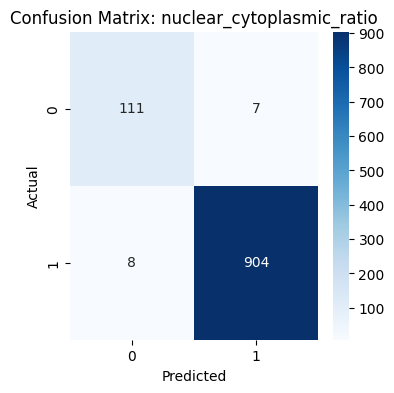

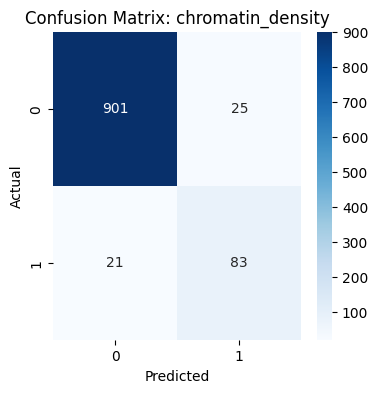

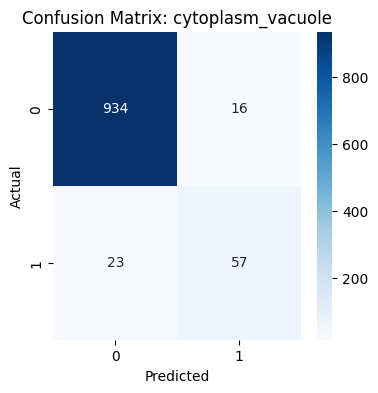

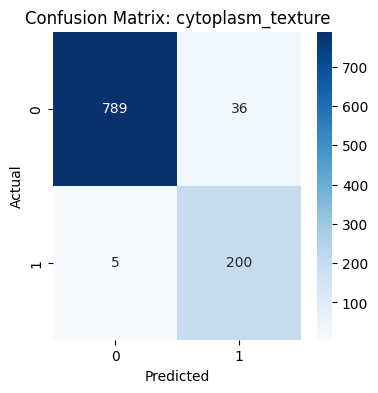

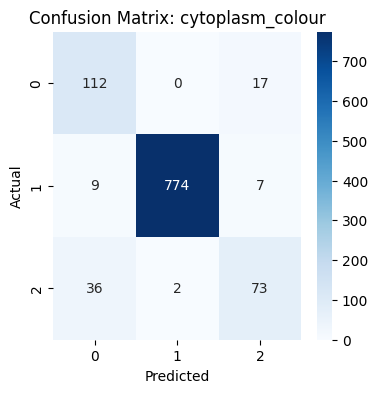

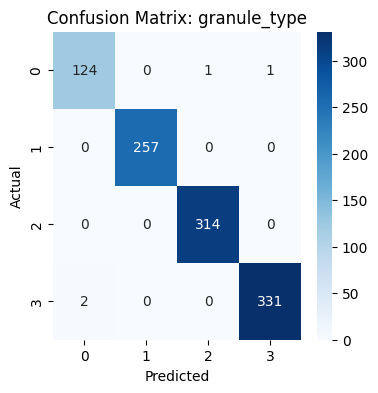

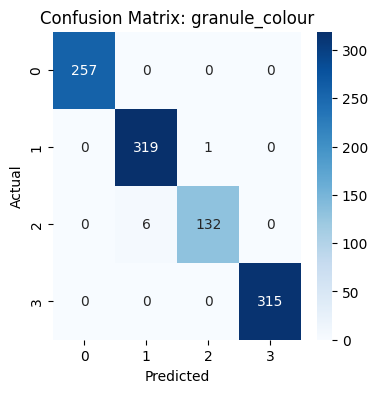

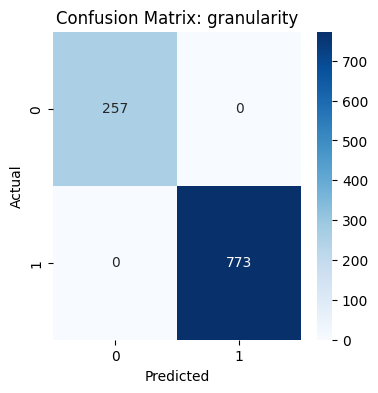


=== Attribute-wise Metrics ===
                    Attribute  Accuracy  F1-Score  Precision
0                   cell_size  0.842718  0.840777   0.847942
1                  cell_shape  0.922330  0.922778   0.923369
2               nucleus_shape  0.768932  0.764282   0.784717
3   nuclear_cytoplasmic_ratio  0.985437  0.985464   0.985495
4           chromatin_density  0.955340  0.955713   0.956150
5           cytoplasm_vacuole  0.962136  0.961339   0.960810
6           cytoplasm_texture  0.960194  0.961212   0.964596
7            cytoplasm_colour  0.931068  0.931911   0.935462
8                granule_type  0.996117  0.996115   0.996117
9              granule_colour  0.993204  0.993168   0.993257
10                granularity  1.000000  1.000000   1.000000


In [ ]:
model.to(device)

# Call the evaluation function on your validation loader
metrics_df = evaluate(model, val_loader, att_names, device)


In [ ]:
def evaluate_attributes_per_cell(
    model,
    loader,
    att_names,
    cell_encoder,
    device
):
    model.eval()

    cell_decoder = {v: k for k, v in cell_encoder.items()}

    # Storage per cell type
    data = {
        c: {
            "attr_probs": [[] for _ in att_names],
            "attr_labels": [[] for _ in att_names]
        }
        for c in cell_decoder.keys()
    }

    with torch.no_grad():
        for batch in loader:
            imgs = batch["image"].to(device)
            cell_targets = batch["cell_type"].cpu().numpy()
            attr_targets = batch["attributes"].cpu().numpy()

            _, attr_outputs = model(imgs)

            for i, out in enumerate(attr_outputs):
                probs = torch.softmax(out, dim=1).cpu().numpy()

                for j, cell_id in enumerate(cell_targets):
                    data[cell_id]["attr_probs"][i].append(probs[j])
                    data[cell_id]["attr_labels"][i].append(attr_targets[j, i])

    rows = []

    for cell_id, cell_name in cell_decoder.items():
        for i, att_name in enumerate(att_names):

            if len(data[cell_id]["attr_labels"][i]) == 0:
                continue

            preds = np.argmax(
                data[cell_id]["attr_probs"][i],
                axis=1
            )
            labels = data[cell_id]["attr_labels"][i]

            rows.append([
    cell_name,
    att_name,
    accuracy_score(labels, preds),
    f1_score(labels, preds, average="weighted", zero_division=0),
    precision_score(labels, preds, average="weighted", zero_division=0)
])


    df = pd.DataFrame(
        rows,
        columns=["Cell Type", "Attribute", "Accuracy", "F1-Score", "Precision"]
    )

    print("\n=== ATTRIBUTE PERFORMANCE PER CELL TYPE ===")
    print(df)

    return df


In [ ]:
attr_cell_df = evaluate_attributes_per_cell(
    model,
    val_loader,
    att_names,
    train_ds.cell_encoder,
    device
)



=== ATTRIBUTE PERFORMANCE PER CELL TYPE ===
     Cell Type                  Attribute  Accuracy  F1-Score  Precision
0     Basophil                  cell_size  0.856000  0.849874   0.849125
1     Basophil                 cell_shape  0.896000  0.868371   0.882727
2     Basophil              nucleus_shape  0.552000  0.523226   0.577820
3     Basophil  nuclear_cytoplasmic_ratio  0.984000  0.984000   0.984000
4     Basophil          chromatin_density  1.000000  1.000000   1.000000
5     Basophil          cytoplasm_vacuole  1.000000  1.000000   1.000000
6     Basophil          cytoplasm_texture  1.000000  1.000000   1.000000
7     Basophil           cytoplasm_colour  1.000000  1.000000   1.000000
8     Basophil               granule_type  0.984000  0.984000   0.984000
9     Basophil             granule_colour  1.000000  1.000000   1.000000
10    Basophil                granularity  1.000000  1.000000   1.000000
11  Eosinophil                  cell_size  0.748408  0.727561   0.764549
12  Eo